In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.linear_model import LogisticRegression

X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()

model = LogisticRegression(class_weight= 'balanced', max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [16]:
#Extract the coefficients
feature_names = X_train.columns
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

In [17]:
#create a absolute value coefficient column and sort in descending order
feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

feature_importance.head(10)

,Feature,Coefficient,abs_coef
24,Contract_Two year,-1.734065,1.734065
9,InternetService_Fiber optic,1.241997,1.241997
23,Contract_One year,-0.813972,0.813972
29,tenure_groups_0-1 year,0.630744,0.630744
31,tenure_groups_2-3 years,-0.471570,0.471570
22,StreamingMovies_Yes,0.447997,0.447997
20,StreamingTV_Yes,0.425691,0.425691
27,PaymentMethod_Electronic check,0.414898,0.414898
2,TotalCharges,-0.383658,0.383658
8,MultipleLines_Yes,0.358740,0.358740


Text(0, 0.5, 'Feature')

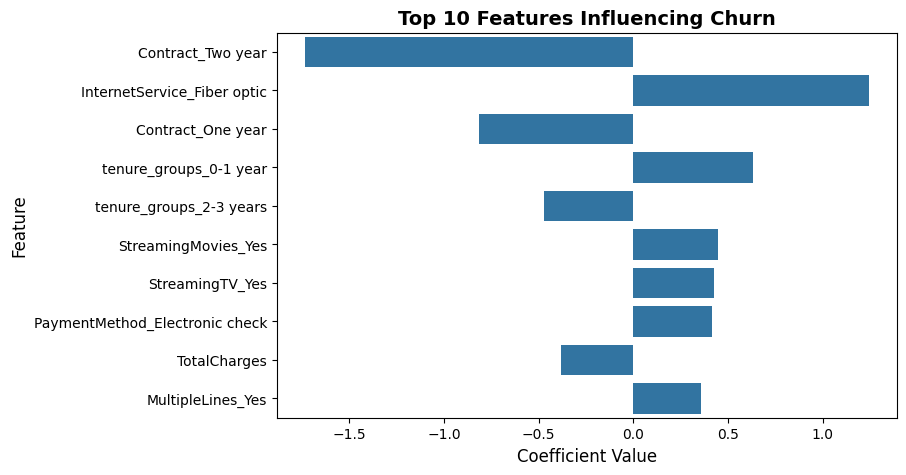

In [ ]:
#plot showing top 10 features influencing churn
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title("Top 10 Features Influencing Churn", fontweight='bold', fontsize=14)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)

## Key Drivers of Customer Churn

After analyzing our logistic regression model, here are the most important factors that predict customer churn:

### Factors That Increase Churn Risk
- **Fiber optic internet** - Customers with fiber optic service are much more likely to churn, possibly due to higher prices or competitive offers
- **New customers (0-1 year)** - First-year customers show high churn risk as they're still evaluating the service
- **Streaming services** - Both streaming movies and TV customers have higher churn rates
- **Electronic check payment** - Customers paying by electronic check are more likely to churn compared to those with automatic payments
- **Multiple lines** - Customers with multiple phone lines show slightly higher churn risk

### Factors That Reduce Churn Risk
- **Long-term contracts** - Two-year contracts are the strongest protector against churn, followed by one-year contracts
- **Established customers (2-3 years)** - Customers who make it to their second and third year become significantly more loyal
- **Higher total charges** - Customers with higher lifetime value are slightly less likely to churn